Analyzing the first 12 CSV files: ['region_1026.0.csv', 'region_53.0.csv', 'region_2001.0.csv', 'region_2021.0.csv', 'region_1023.0.csv', 'region_1008.0.csv', 'region_52.0.csv', 'region_1028.0.csv', 'region_1021.0.csv', 'region_2013.0.csv', 'region_2030.0.csv', 'region_2012.0.csv']
Region 1026.0:
  T-statistic: -0.0088, P-value: 0.9930
  No significant difference.
Region 53.0:
  T-statistic: 0.0112, P-value: 0.9911
  No significant difference.
Region 2001.0:
  T-statistic: 0.1101, P-value: 0.9124
  No significant difference.
Region 2021.0:
  T-statistic: 0.0272, P-value: 0.9783
  No significant difference.
Region 1023.0:
  T-statistic: 0.1713, P-value: 0.8640
  No significant difference.
Region 1008.0:
  T-statistic: -0.1257, P-value: 0.9000
  No significant difference.
Region 52.0:
  T-statistic: -0.0528, P-value: 0.9579
  No significant difference.
Region 1028.0:
  T-statistic: 0.0916, P-value: 0.9270
  No significant difference.
Region 1021.0:
  T-statistic: -0.1199, P-value: 0.9046

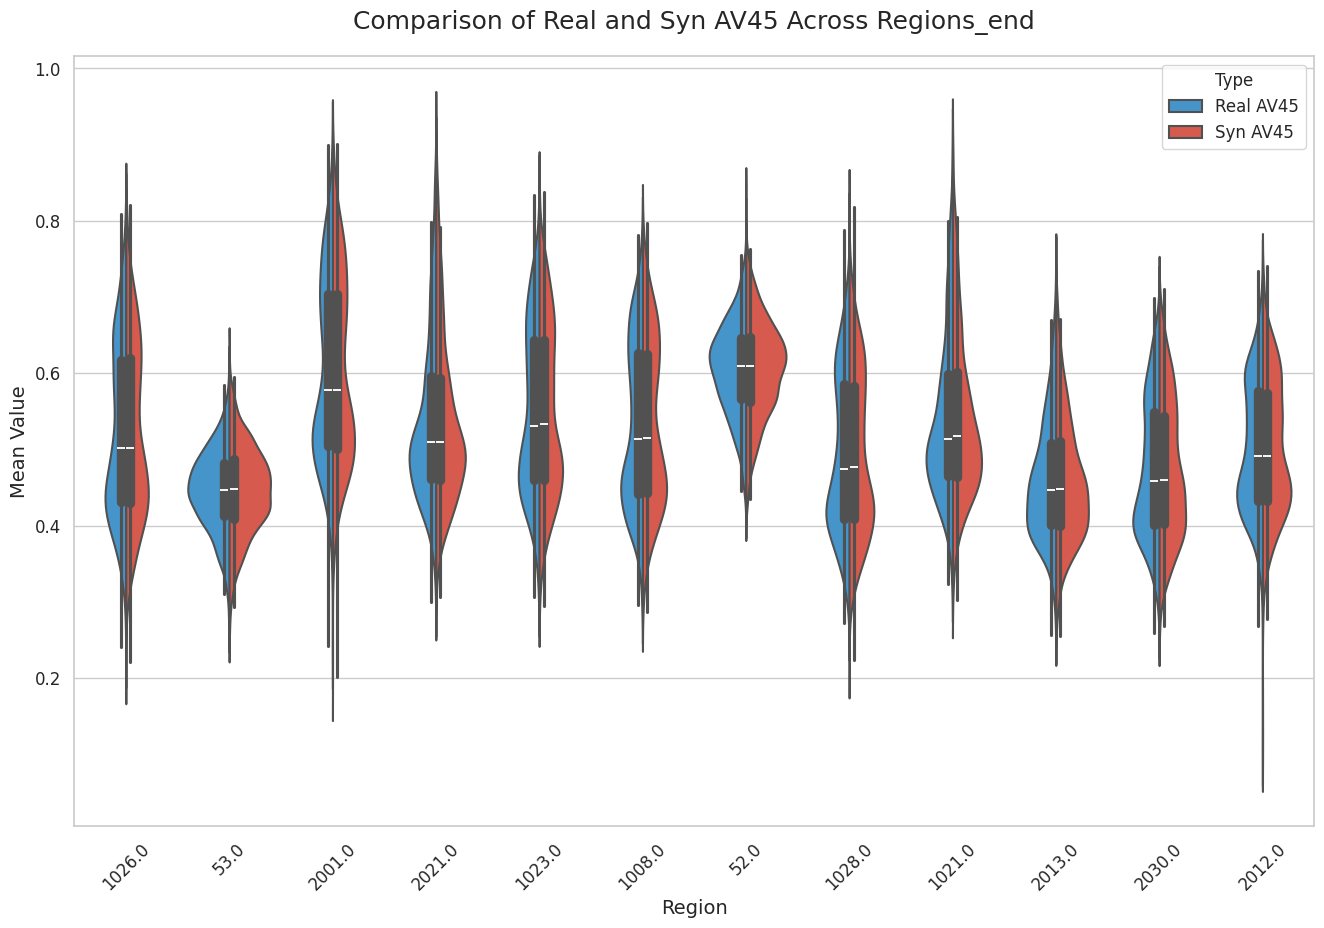

In [31]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

# 定义路径
output_dir = "/home/ssddata/liutuo/liutuo_data/statistics_of_regions_av45_adjust"

# 加载 CSV 文件
def load_csv(file_path):
    return pd.read_csv(file_path)

# 统计检验和绘图
def analyze_and_plot():
    # 获取目录中的所有 CSV 文件
    csv_files = [f for f in os.listdir(output_dir) if f.endswith(".csv")]
    
    # 如果没有 CSV 文件，直接退出
    if not csv_files:
        print("No CSV files found in the directory.")
        return

    # 只取前 12 个 CSV 文件
    csv_files = csv_files[86:]
    print(f"Analyzing the first 12 CSV files: {csv_files}")

    # 创建一个 DataFrame 存储所有数据
    all_data = []

    # 用于保存显著性信息
    significance_info = {}

    for csv_file in csv_files:
        csv_path = os.path.join(output_dir, csv_file)
        if not os.path.exists(csv_path):
            print(f"File not found: {csv_path}")
            continue

        # 提取区域名称（去掉 "region_" 和 ".csv"）
        region = os.path.splitext(csv_file)[0].replace("region_", "")

        csv_data = load_csv(csv_path)
        real_av45 = csv_data["real_av45_mean"].values
        syn_av45 = csv_data["syn_av45_mean"].values

        # 独立样本 t 检验
        t_stat, p_value = ttest_ind(real_av45, syn_av45)
        print(f"Region {region}:")
        print(f"  T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")
        if p_value < 0.05:
            print("  Significant difference detected!")
            significance_info[region] = "Significant"
        else:
            print("  No significant difference.")
            significance_info[region] = "Not Significant"

        # 合并数据为长格式
        data = pd.DataFrame({
            "Real AV45": real_av45,
            "Syn AV45": syn_av45
        }).melt(var_name="Type", value_name="Mean Value")

        # 添加区域标签
        data["Region"] = region

        # 将数据追加到总数据集
        all_data.append(data)

    # 合并所有数据
    combined_data = pd.concat(all_data, ignore_index=True)

    # 设置 Seaborn 主题和颜色
    sns.set_theme(style="whitegrid")
    # 自定义颜色方案
    palette = {"Real AV45": "#3498DB", "Syn AV45": "#E74C3C"}  # 蓝色和红色

    # 绘制小提琴图 + 箱线图
    plt.figure(figsize=(16, 10))
    ax = sns.violinplot(
        data=combined_data,
        x="Region",
        y="Mean Value",
        hue="Type",
        inner="box",
        split=True,
        palette=palette,
        linewidth=1.5,
        saturation=0.8
    )

    # 添加显著性标注
    y_max = combined_data["Mean Value"].max() * 1.1  # 动态计算 y 轴最大值
    for i, region in enumerate(significance_info.keys()):
        if significance_info[region] == "Significant":
            plt.text(i, y_max, "*", ha="center", fontsize=16, color="red", fontweight="bold")

    # 在第一个箱型图上添加红星
    # 获取第一个箱型图的最大值
    # first_region_data = combined_data[combined_data["Region"] == combined_data["Region"].unique()[10]]
    # first_region_max = first_region_data["Mean Value"].max()
    # # 添加红星
    # plt.text(10, first_region_max + 0.1, "*", ha="center", fontsize=24, color="red", fontweight="bold")

    # 图形细节优化
    plt.title("Comparison of Real and Syn AV45 Across Regions_end", fontsize=18, pad=20)
    plt.ylabel("Mean Value", fontsize=14)
    plt.xlabel("Region", fontsize=14)
    plt.xticks(fontsize=12, rotation=45)  # 旋转 x 轴标签以便更好显示
    plt.yticks(fontsize=12)
    plt.legend(title="Type", title_fontsize=12, fontsize=12, loc="upper right", frameon=True)

    # 保存图像
    plot_path = os.path.join(output_dir, "regions_comparison_violin_first_end.png")
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    print(f"Saved plot to {plot_path}")

    # 显示图像
    plt.show()

# 主逻辑
analyze_and_plot()

Analyzing the first 12 CSV files: ['region_1026.0.csv', 'region_53.0.csv', 'region_2001.0.csv', 'region_2021.0.csv', 'region_1023.0.csv', 'region_1008.0.csv', 'region_52.0.csv', 'region_1028.0.csv', 'region_1021.0.csv', 'region_2013.0.csv', 'region_2030.0.csv', 'region_2012.0.csv']
Region 1026.0:
  T-statistic: nan, P-value: nan
  No significant difference.
Region 53.0:
  T-statistic: 0.0237, P-value: 0.9811
  No significant difference.
Region 2001.0:
  T-statistic: 0.0449, P-value: 0.9642
  No significant difference.
Region 2021.0:
  T-statistic: 0.3693, P-value: 0.7119
  No significant difference.
Region 1023.0:
  T-statistic: 0.2046, P-value: 0.8379
  No significant difference.
Region 1008.0:
  T-statistic: 0.0272, P-value: 0.9783
  No significant difference.
Region 52.0:
  T-statistic: nan, P-value: nan
  No significant difference.
Region 1028.0:
  T-statistic: -0.4363, P-value: 0.6626
  No significant difference.
Region 1021.0:
  T-statistic: 0.0381, P-value: 0.9696
  No significa

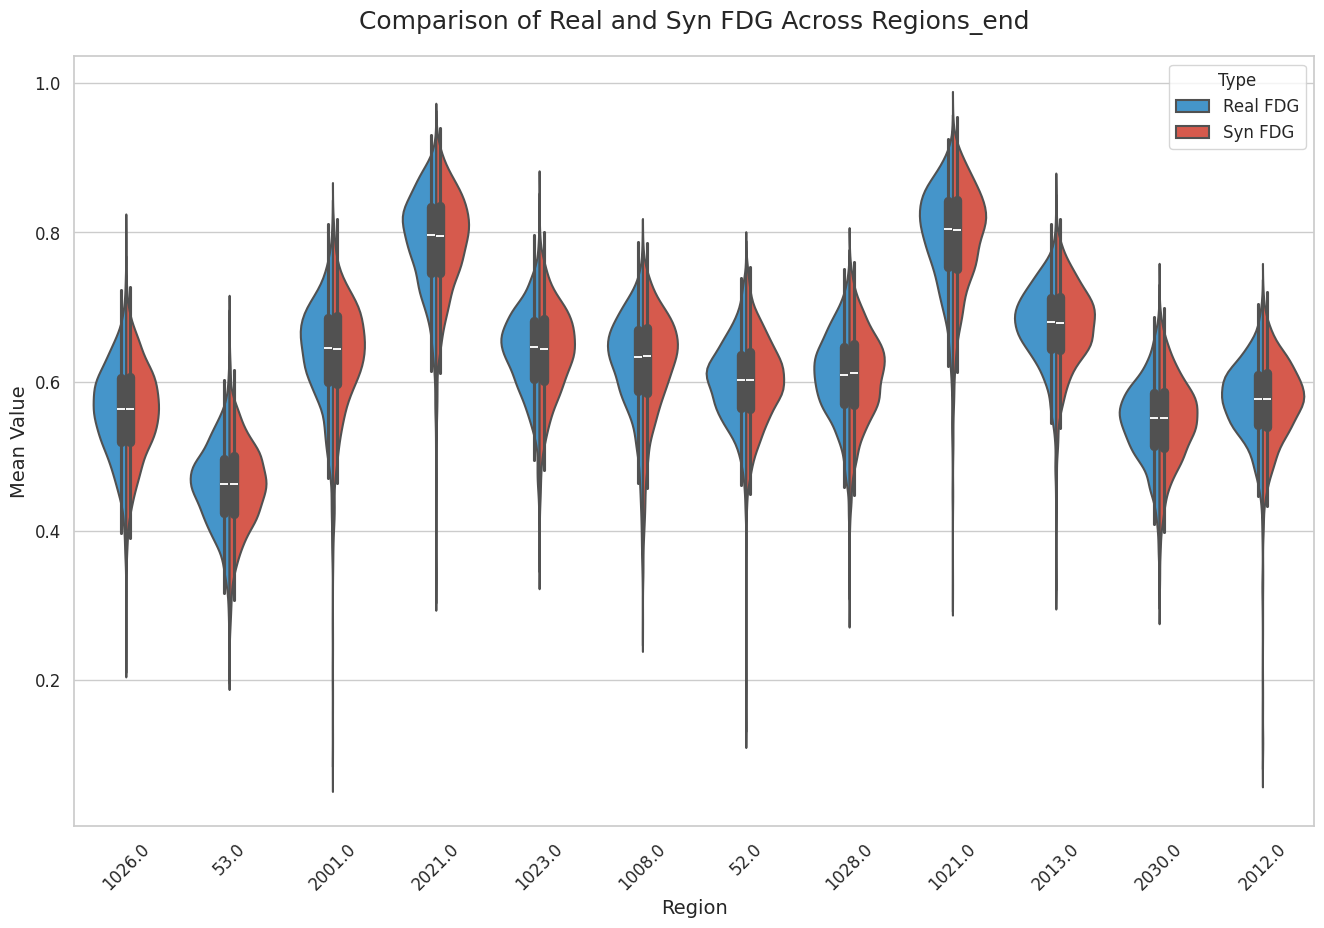

In [34]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

# 定义路径（假设目录名仍包含 av45，但 CSV 内容是 FDG）
output_dir = "/home/ssddata/liutuo/liutuo_data/statistics_of_regions_fdg_adjust"

# 加载 CSV 文件
def load_csv(file_path):
    return pd.read_csv(file_path)

# 统计检验和绘图
def analyze_and_plot():
    # 获取目录中的所有 CSV 文件
    csv_files = [f for f in os.listdir(output_dir) if f.endswith(".csv")]
    
    # 如果没有 CSV 文件，直接退出
    if not csv_files:
        print("No CSV files found in the directory.")
        return

    # 只取前 12 个 CSV 文件（从第 86 个开始）
    csv_files = csv_files[86:]
    print(f"Analyzing the first 12 CSV files: {csv_files}")

    # 创建一个 DataFrame 存储所有数据
    all_data = []

    # 用于保存显著性信息
    significance_info = {}

    for csv_file in csv_files:
        csv_path = os.path.join(output_dir, csv_file)
        if not os.path.exists(csv_path):
            print(f"File not found: {csv_path}")
            continue

        # 提取区域名称（去掉 "region_" 和 ".csv"）
        region = os.path.splitext(csv_file)[0].replace("region_", "")

        csv_data = load_csv(csv_path)
        real_fdg = csv_data["real_fdg_mean"].values
        syn_fdg = csv_data["syn_fdg_mean"].values

        # 独立样本 t 检验
        t_stat, p_value = ttest_ind(real_fdg, syn_fdg)
        print(f"Region {region}:")
        print(f"  T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")
        if p_value < 0.05:
            print("  Significant difference detected!")
            significance_info[region] = "Significant"
        else:
            print("  No significant difference.")
            significance_info[region] = "Not Significant"

        # 合并数据为长格式
        data = pd.DataFrame({
            "Real FDG": real_fdg,
            "Syn FDG": syn_fdg
        }).melt(var_name="Type", value_name="Mean Value")

        # 添加区域标签
        data["Region"] = region

        # 将数据追加到总数据集
        all_data.append(data)

    # 合并所有数据
    combined_data = pd.concat(all_data, ignore_index=True)

    # 设置 Seaborn 主题和颜色
    sns.set_theme(style="whitegrid")
    # 自定义颜色方案
    palette = {"Real FDG": "#3498DB", "Syn FDG": "#E74C3C"}  # 蓝色和红色

    # 绘制小提琴图 + 箱线图
    plt.figure(figsize=(16, 10))
    ax = sns.violinplot(
        data=combined_data,
        x="Region",
        y="Mean Value",
        hue="Type",
        inner="box",
        split=True,
        palette=palette,
        linewidth=1.5,
        saturation=0.8
    )

    # 添加显著性标注
    y_max = combined_data["Mean Value"].max() * 1.1  # 动态计算 y 轴最大值
    for i, region in enumerate(significance_info.keys()):
        if significance_info[region] == "Significant":
            plt.text(i, y_max, "*", ha="center", fontsize=16, color="red", fontweight="bold")

    # 图形细节优化
    plt.title("Comparison of Real and Syn FDG Across Regions_end", fontsize=18, pad=20)
    plt.ylabel("Mean Value", fontsize=14)
    plt.xlabel("Region", fontsize=14)
    plt.xticks(fontsize=12, rotation=45)  # 旋转 x 轴标签以便更好显示
    plt.yticks(fontsize=12)
    plt.legend(title="Type", title_fontsize=12, fontsize=12, loc="upper right", frameon=True)

    # 保存图像
    plot_path = os.path.join(output_dir, "regions_comparison_violin_first_end.png")
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    print(f"Saved plot to {plot_path}")

    # 显示图像
    plt.show()

# 主逻辑
analyze_and_plot()

Analyzing 12 regions: ['region_47.0.csv', 'region_49.0.csv', 'region_5.0.csv', 'region_50.0.csv', 'region_51.0.csv', 'region_52.0.csv', 'region_53.0.csv', 'region_54.0.csv', 'region_58.0.csv', 'region_60.0.csv', 'region_7.0.csv', 'region_8.0.csv']
47.0: t=-0.091, p=0.9276 → ns
49.0: t=0.372, p=0.7103 → ns
5.0: t=-0.190, p=0.8495 → ns
50.0: t=-0.143, p=0.8867 → ns
51.0: t=0.444, p=0.6572 → ns
52.0: t=-0.053, p=0.9579 → ns
53.0: t=0.011, p=0.9911 → ns
54.0: t=-0.082, p=0.9347 → ns
58.0: t=0.176, p=0.8603 → ns
60.0: t=-0.440, p=0.6599 → ns
7.0: t=nan, p=nan → ns
8.0: t=0.440, p=0.6602 → ns

Plot saved to: /home/ssddata/liutuo/liutuo_data/shuijin/statistics_of_regions_av45_adjust/regions_comparison_violin_significance_adjusted.png


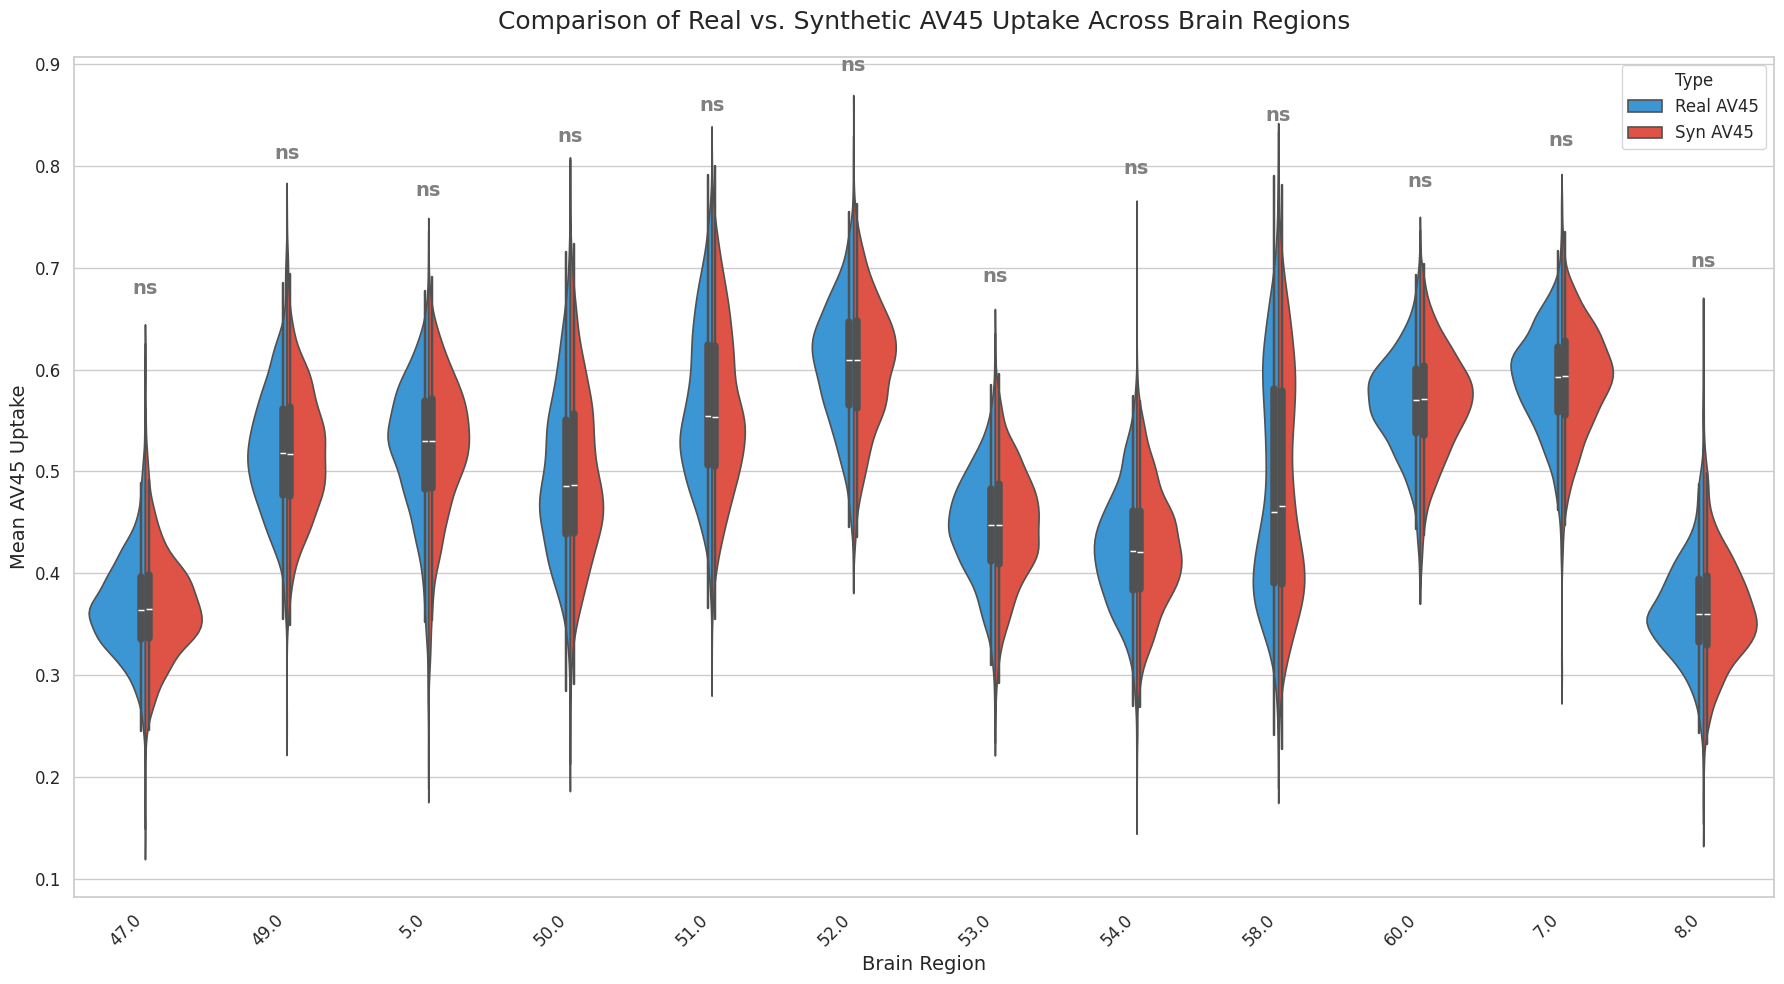

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

# 设置路径
output_dir = "/home/ssddata/liutuo/liutuo_data/shuijin/statistics_of_regions_av45_adjust"

# 加载 CSV
def load_csv(file_path):
    return pd.read_csv(file_path)

def analyze_and_plot():
    # 获取所有 CSV
    csv_files = [f for f in os.listdir(output_dir) if f.endswith(".csv")]
    if not csv_files:
        print("No CSV files found.")
        return

    # 从第 86 个开始（你可以根据需要调整）
    csv_files = sorted(csv_files)[86:]  # 推荐加 sorted 保证顺序
    print(f"Analyzing {len(csv_files)} regions: {csv_files}")

    all_data = []
    significance_labels = {}

    for csv_file in csv_files:
        csv_path = os.path.join(output_dir, csv_file)
        if not os.path.exists(csv_path):
            print(f"Skip missing file: {csv_path}")
            continue

        # 提取区域名：如 "region_prefrontal.csv" -> "prefrontal"
        region = os.path.splitext(csv_file)[0].replace("region_", "")

        # 读取数据
        df = load_csv(csv_path)
        real_av45 = df["real_av45_mean"].values
        syn_av45 = df["syn_av45_mean"].values

        # t 检验（Welch's t-test）
        t_stat, p_val = ttest_ind(real_av45, syn_av45, equal_var=False)

        # 显著性标签
        if p_val < 0.001:
            sig = "***"
        elif p_val < 0.01:
            sig = "**"
        elif p_val < 0.05:
            sig = "*"
        else:
            sig = "ns"
        significance_labels[region] = sig

        # 打印结果
        print(f"{region}: t={t_stat:.3f}, p={p_val:.4f} → {sig}")

        # 转为长格式
        data_long = pd.DataFrame({
            "Real AV45": real_av45,
            "Syn AV45": syn_av45
        }).melt(var_name="Type", value_name="Mean Value")
        data_long["Region"] = region
        all_data.append(data_long)

    if not all_data:
        print("No valid data to plot.")
        return

    # 合并数据
    combined_df = pd.concat(all_data, ignore_index=True)

    # 绘图设置
    sns.set_theme(style="whitegrid")
    palette = {"Real AV45": "#3498DB", "Syn AV45": "#E74C3C"}
    plt.figure(figsize=(18, 10))

    # 小提琴图 + 箱线图
    ax = sns.violinplot(
        data=combined_df,
        x="Region",
        y="Mean Value",
        hue="Type",
        inner="box",
        split=True,
        palette=palette,
        linewidth=1.2,
        saturation=0.9
    )

    # 动态标注显著性（每个区域独立高度）
    regions = combined_df["Region"].unique()
    for i, region in enumerate(regions):
        label = significance_labels[region]
        color = "black" if label != "ns" else "gray"

        # 获取该区域最大值，向上偏移 0.05（根据你的数据尺度调整）
        region_max = combined_df[combined_df["Region"] == region]["Mean Value"].max()
        y_pos = region_max + 0.05

        plt.text(i, y_pos, label, ha="center", va="bottom",
                 fontsize=14, color=color, fontweight="bold")

    # 图形美化
    plt.title("Comparison of Real vs. Synthetic AV45 Uptake Across Brain Regions", 
              fontsize=18, pad=20)
    plt.xlabel("Brain Region", fontsize=14)
    plt.ylabel("Mean AV45 Uptake", fontsize=14)
    plt.xticks(rotation=45, ha="right", fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(title="Type", title_fontsize=12, fontsize=12, 
               loc="upper right", frameon=True)

    # 保存
    plot_path = os.path.join(output_dir, "regions_comparison_violin_significance_adjusted.png")
    plt.tight_layout()
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    print(f"\nPlot saved to: {plot_path}")
    plt.show()

# 运行
if __name__ == "__main__":
    analyze_and_plot()

Analyzing 12 regions: ['region_47.0.csv', 'region_49.0.csv', 'region_5.0.csv', 'region_50.0.csv', 'region_51.0.csv', 'region_52.0.csv', 'region_53.0.csv', 'region_54.0.csv', 'region_58.0.csv', 'region_60.0.csv', 'region_7.0.csv', 'region_8.0.csv']
Saved: /home/ssddata/liutuo/liutuo_data/shuijin/statistics_of_regions_av45_adjust/cn_vs_mci_real_av45_violin.png


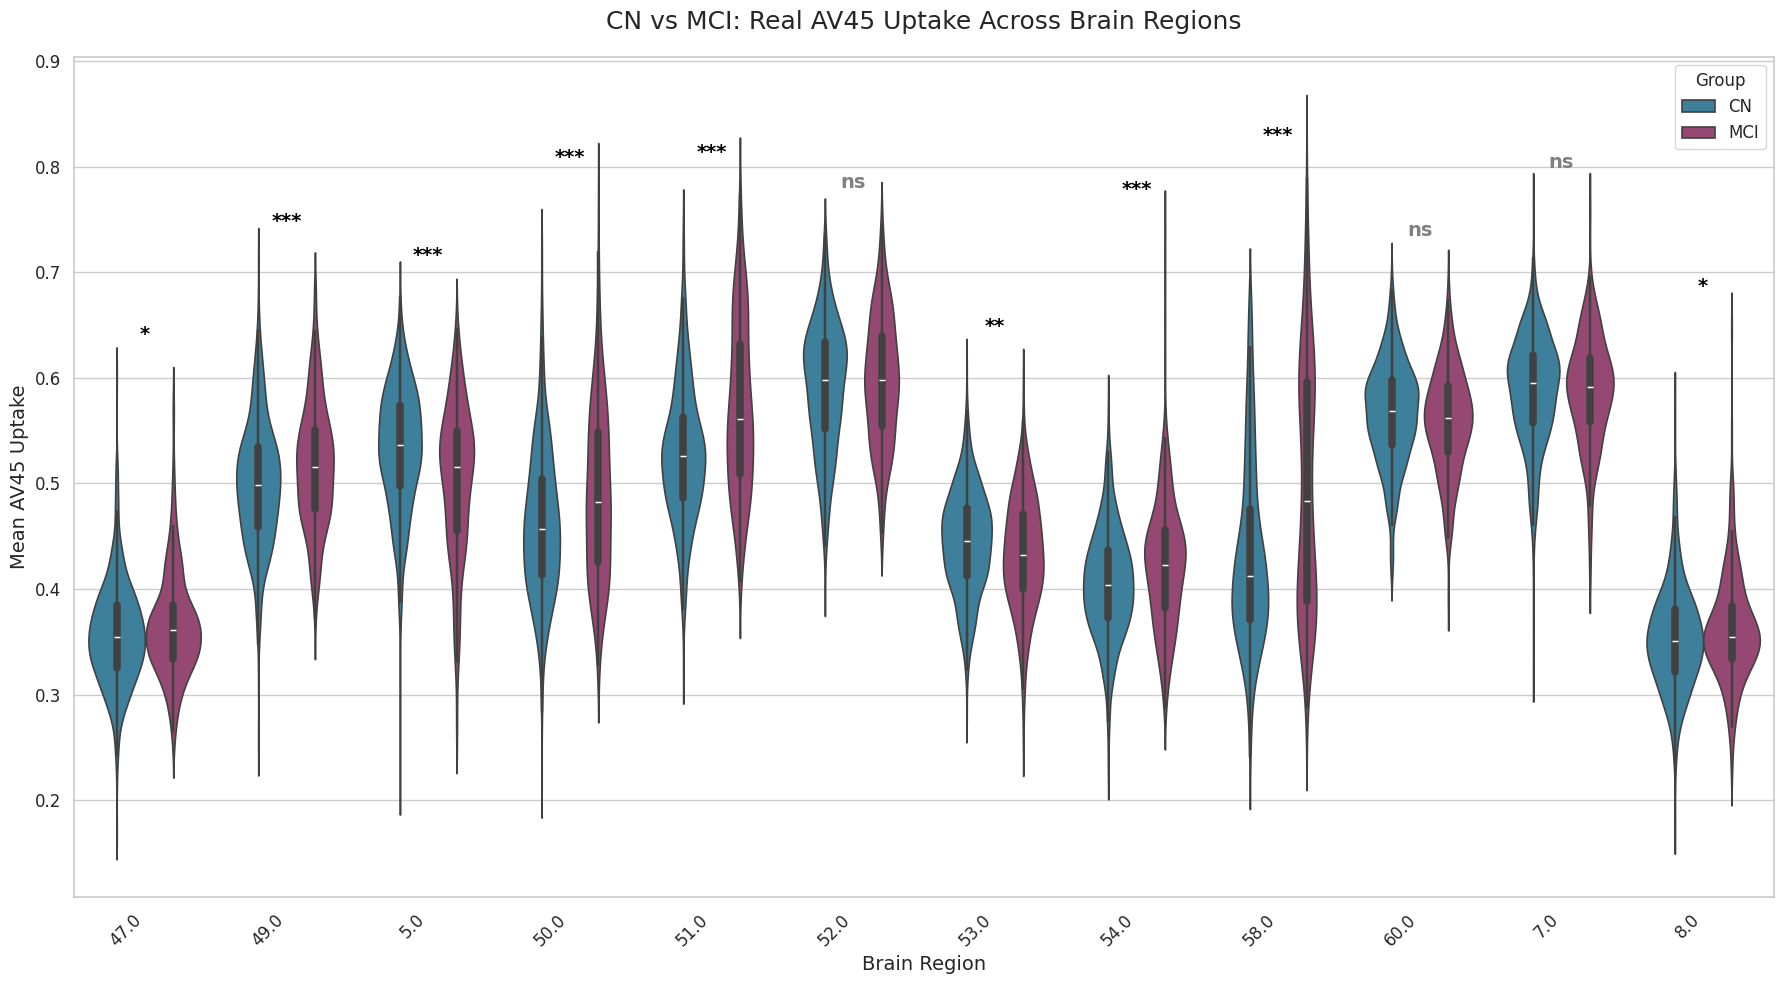

Saved: /home/ssddata/liutuo/liutuo_data/shuijin/statistics_of_regions_av45_adjust/cn_vs_mci_syn_av45_violin.png


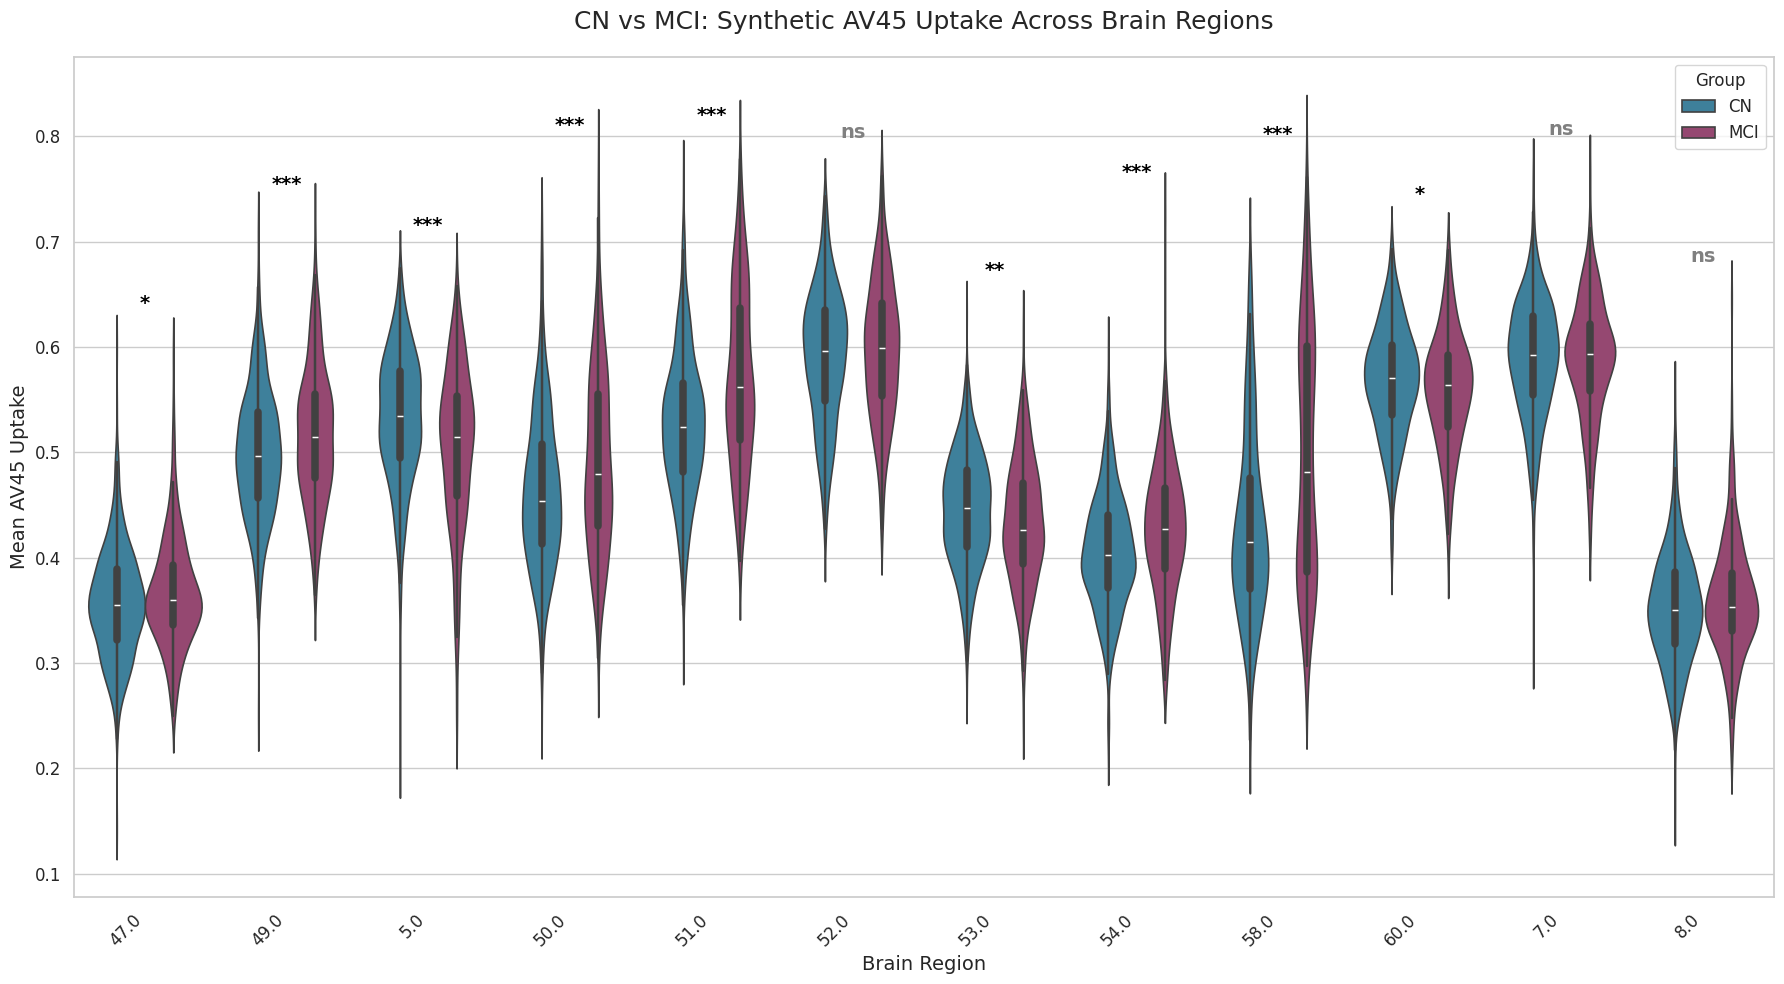

In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

# 设置路径
output_dir = "/home/ssddata/liutuo/liutuo_data/shuijin/statistics_of_regions_av45_adjust"

def get_significance_label(p_val):
    if p_val < 0.001:
        return "***"
    elif p_val < 0.01:
        return "**"
    elif p_val < 0.05:
        return "*"
    else:
        return "ns"

def analyze_cn_vs_mci():
    csv_files = [f for f in os.listdir(output_dir) if f.endswith(".csv")]
    if not csv_files:
        print("No CSV files found.")
        return

    # 可选：只处理特定区域，比如从第86个开始（按你原逻辑）
    csv_files = sorted(csv_files)[86:]
    print(f"Analyzing {len(csv_files)} regions: {csv_files}")

    # 定义要比较的组
    GROUPS_OF_INTEREST = ['CN', 'MCI']
    # 如果你的MCI分散在EMCI/LMCI，取消注释下面这行
    # GROUP_MAP = {'EMCI': 'MCI', 'LMCI': 'MCI', 'MCI': 'MCI', 'CN': 'CN'}

    all_real_data = []
    all_syn_data = []
    real_sig_labels = {}
    syn_sig_labels = {}

    for csv_file in csv_files:
        csv_path = os.path.join(output_dir, csv_file)
        if not os.path.exists(csv_path):
            continue

        region = os.path.splitext(csv_file)[0].replace("region_", "")
        df = pd.read_csv(csv_path)

        # 确保有 Research Group 列
        if 'Research Group' not in df.columns:
            print(f"Warning: {csv_file} missing 'Research Group', skip.")
            continue

        # 可选：合并 EMCI/LMCI 到 MCI
        # df['Research Group'] = df['Research Group'].map(GROUP_MAP).dropna()

        # 只保留 CN 和 MCI
        df_filtered = df[df['Research Group'].isin(GROUPS_OF_INTEREST)].copy()
        if len(df_filtered) < 2:
            print(f"Skip {region}: not enough CN/MCI samples.")
            continue

        # 确保两组都存在
        groups_present = df_filtered['Research Group'].unique()
        if not {'CN', 'MCI'}.issubset(groups_present):
            print(f"Skip {region}: missing CN or MCI.")
            continue

        # 提取 real 和 syn 数据（长格式）
        real_long = df_filtered[['Research Group', 'real_av45_mean']].rename(
            columns={'real_av45_mean': 'Value'}
        )
        real_long['Region'] = region
        real_long['Metric'] = 'Real AV45'
        all_real_data.append(real_long)

        syn_long = df_filtered[['Research Group', 'syn_av45_mean']].rename(
            columns={'syn_av45_mean': 'Value'}
        )
        syn_long['Region'] = region
        syn_long['Metric'] = 'Syn AV45'
        all_syn_data.append(syn_long)

        # === t 检验: CN vs MCI for real ===
        cn_real = df_filtered[df_filtered['Research Group'] == 'CN']['real_av45_mean'].dropna()
        mci_real = df_filtered[df_filtered['Research Group'] == 'MCI']['real_av45_mean'].dropna()
        if len(cn_real) > 0 and len(mci_real) > 0:
            _, p_real = ttest_ind(cn_real, mci_real, equal_var=False)
            real_sig_labels[region] = get_significance_label(p_real)
        else:
            real_sig_labels[region] = "ns"

        # === t 检验: CN vs MCI for syn ===
        cn_syn = df_filtered[df_filtered['Research Group'] == 'CN']['syn_av45_mean'].dropna()
        mci_syn = df_filtered[df_filtered['Research Group'] == 'MCI']['syn_av45_mean'].dropna()
        if len(cn_syn) > 0 and len(mci_syn) > 0:
            _, p_syn = ttest_ind(cn_syn, mci_syn, equal_var=False)
            syn_sig_labels[region] = get_significance_label(p_syn)
        else:
            syn_sig_labels[region] = "ns"

    if not all_real_data:
        print("No valid data for plotting.")
        return

    # 合并数据
    df_real = pd.concat(all_real_data, ignore_index=True)
    df_syn = pd.concat(all_syn_data, ignore_index=True)

    # 绘图函数
    def plot_metric(df, sig_labels, title, filename):
        plt.figure(figsize=(18, 10))
        sns.set_theme(style="whitegrid")
        palette = {"CN": "#2E86AB", "MCI": "#A23B72"}  # 蓝 vs 紫

        ax = sns.violinplot(
            data=df,
            x="Region",
            y="Value",
            hue="Research Group",
            inner="box",
            split=False,  # 不 split，因为不是配对数据
            palette=palette,
            linewidth=1.2
        )

        # 标注显著性（在每组区域上方）
        regions = df["Region"].unique()
        for i, region in enumerate(regions):
            label = sig_labels.get(region, "ns")
            color = "black" if label != "ns" else "gray"
            # 计算该区域最大值
            max_val = df[df["Region"] == region]["Value"].max()
            y_pos = max_val + (df["Value"].max() - df["Value"].min()) * 0.05  # 动态偏移
            plt.text(i, y_pos, label, ha="center", va="bottom",
                     fontsize=14, color=color, fontweight="bold")

        plt.title(title, fontsize=18, pad=20)
        plt.xlabel("Brain Region", fontsize=14)
        plt.ylabel("Mean AV45 Uptake", fontsize=14)
        plt.xticks(rotation=45, ha="right", fontsize=12)
        plt.yticks(fontsize=12)
        plt.legend(title="Group", title_fontsize=12, fontsize=12, loc="upper right")

        plt.tight_layout()
        plot_path = os.path.join(output_dir, filename)
        plt.savefig(plot_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {plot_path}")
        plt.show()

    # 绘制两个图
    plot_metric(
        df_real, real_sig_labels,
        "CN vs MCI: Real AV45 Uptake Across Brain Regions",
        "cn_vs_mci_real_av45_violin.png"
    )

    plot_metric(
        df_syn, syn_sig_labels,
        "CN vs MCI: Synthetic AV45 Uptake Across Brain Regions",
        "cn_vs_mci_syn_av45_violin.png"
    )

if __name__ == "__main__":
    analyze_cn_vs_mci()